# Tugas Data Mining II TM9 - Image Classification

## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A2

### ---- 0. Imports & Config ----

In [1]:
import os, random, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers
from keras.models import Model, load_model
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.applications import ConvNeXtTiny
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

try:
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
except Exception:
    pass
try:
    from keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    MIXED_PRECISION = True
except Exception:
    MIXED_PRECISION = False


2025-10-28 06:28:31.377414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761632911.578872      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761632911.633653      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### ---- 1. Hyperparams & Paths ----

In [2]:
IMG_SIZE       = 224
BATCH_SIZE     = 64
EPOCHS_WARMUP  = 5
EPOCHS_FT      = 15
LR_WARMUP      = 1e-3
LR_FT          = 3e-5
WD_WARMUP      = 1e-4
WD_FT          = 5e-5
DROPOUT        = 0.35
DENSE_UNITS    = 512
FOLDS          = 2
DO_TUNING      = False
TUNER_TRIALS   = 8
TUNER_EPOCHS   = 6

CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
NUM_CLASSES = 10

### ---- 2. Load CIFAR-10 ----

In [3]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print("Label distribusi (train):", np.bincount(y_train))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Label distribusi (train): [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


### ---- 3. Exploratory Data Analysis (EDA) ----


== EDA: Class distribution (train) ==
class
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64


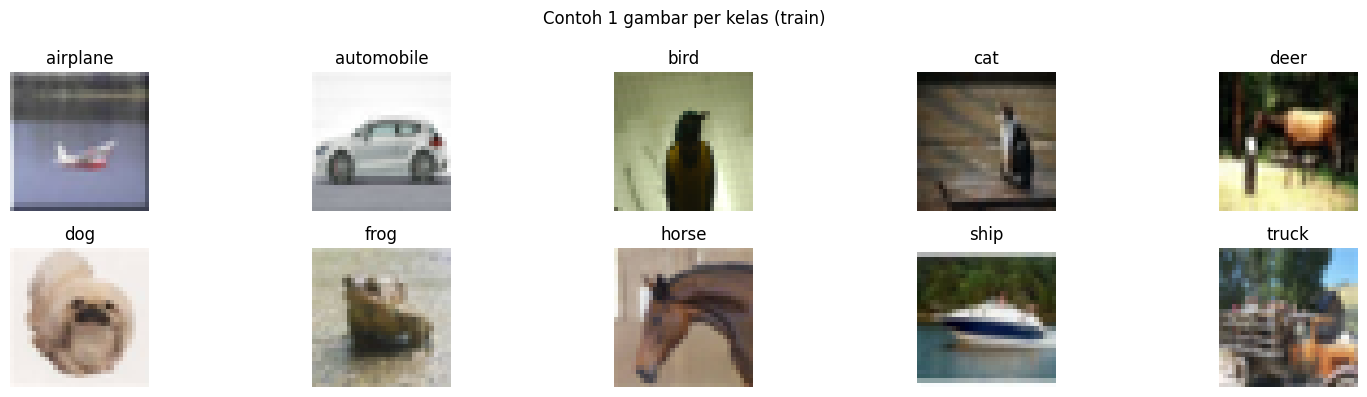

Per-channel mean (RGB): [0.3277 0.3277 0.3277] | std: [0.2776 0.2693 0.2681]


In [4]:
# 3.1 Tabel distribusi kelas
eda_df = pd.DataFrame({"label": y_train})
eda_df["class"] = eda_df["label"].map(lambda i: CLASS_NAMES[i])
print("\n== EDA: Class distribution (train) ==")
print(eda_df["class"].value_counts().sort_index())

# 3.2 Contoh grid gambar per kelas
def plot_samples_per_class(x, y, class_names, ncols=10, seed=SEED):
    np.random.seed(seed)
    plt.figure(figsize=(16, 4))
    for ci, cname in enumerate(class_names):
        idxs = np.where(y == ci)[0]
        i = np.random.choice(idxs)
        img = x[i]
        plt.subplot(2, 5, ci+1)
        plt.imshow(img)
        plt.title(cname); plt.axis('off')
    plt.suptitle("Contoh 1 gambar per kelas (train)"); plt.tight_layout(); plt.show()

plot_samples_per_class(x_train, y_train, CLASS_NAMES)

# 3.3 Statistik piksel (mean/std per channel)
x_train_f = x_train.astype("float32") / 255.0
ch_mean = x_train_f.reshape(-1,3).mean(axis=0)
ch_std  = x_train_f.reshape(-1,3).std(axis=0)
print(f"Per-channel mean (RGB): {ch_mean.round(4)} | std: {ch_std.round(4)}")

### ---- 4. Pre-processing & tf.data ----

In [5]:
# Augmentasi ringan-efektif (mirip pipeline sebelumnya)
AUG = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomTranslation(0.08, 0.08, fill_mode="reflect", seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="augment")

def _preprocess(image, label, training: bool):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    if training:
        image = AUG(image, training=True)
    return image, label

def make_ds(x, y, training=True, shuffle=True, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda a,b: _preprocess(a,b,training), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

I0000 00:00:1761632954.662219      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### ---- 5. Model Builder (ConvNeXt-Tiny) ----

In [6]:
def build_model(dropout=DROPOUT, dense_units=DENSE_UNITS):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = ConvNeXtTiny(include_top=False, weights="imagenet", input_tensor=inputs)
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout)(x)
    x = Dense(dense_units, activation="relu")(x)
    x = Dropout(dropout)(x)
    # out dtype float32 (penting saat mixed precision agar loss/metrics stabil)
    outputs = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    model = Model(inputs, outputs)
    return model, base

### ---- 6. (Opsional) Hyperparameter Tuning dengan KerasTuner ----

In [7]:
best_hp = {"dropout": DROPOUT, "dense_units": DENSE_UNITS,
           "lr_warm": LR_WARMUP, "wd_warm": WD_WARMUP,
           "lr_ft": LR_FT, "wd_ft": WD_FT}

if DO_TUNING:
    try:
        # install bila perlu: pip install keras-tuner
        import kerastuner as kt  # for very old environments
        from kerastuner.tuners import RandomSearch
        _OLD = True
    except Exception:
        try:
            import keras_tuner as kt
            from keras_tuner.tuners import RandomSearch
            _OLD = False
        except Exception as e:
            print("KerasTuner tidak tersedia, lewati tuning. Error:", e)
            DO_TUNING = False

if DO_TUNING:
    # gunakan subset agar cepat
    x_sub, _, y_sub, _ = train_test_split(x_train, y_train, test_size=0.7, random_state=SEED, stratify=y_train)
    x_tr, x_va, y_tr, y_va = train_test_split(x_sub, y_sub, test_size=0.2, random_state=SEED, stratify=y_sub)

    ds_tr = make_ds(x_tr, y_tr, training=True, shuffle=True, batch_size=64)
    ds_va = make_ds(x_va, y_va, training=False, shuffle=False, batch_size=64)

    def tuner_builder(hp):
        hp_dropout = hp.Float("dropout", 0.2, 0.6, step=0.1)
        hp_dense   = hp.Choice("dense_units", [256, 384, 512, 768])
        hp_lr_w    = hp.Choice("lr_warm", [3e-4, 1e-3, 3e-3])
        hp_wd_w    = hp.Choice("wd_warm", [1e-5, 5e-5, 1e-4])
        hp_lr_ft   = hp.Choice("lr_ft", [1e-5, 3e-5, 7e-5])
        hp_wd_ft   = hp.Choice("wd_ft", [1e-5, 5e-5, 1e-4])

        model, base = build_model(dropout=hp_dropout, dense_units=hp_dense)
        base.trainable = False
        opt = keras.optimizers.AdamW(learning_rate=hp_lr_w, weight_decay=hp_wd_w)
        model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

    tuner = RandomSearch(
        tuner_builder,
        objective="val_accuracy",
        max_trials=TUNER_TRIALS,
        directory="ktuner_logs",
        project_name="convnext_cifar10"
    )
    cb = [EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
    tuner.search(ds_tr, epochs=TUNER_EPOCHS, validation_data=ds_va, callbacks=cb, verbose=1)
    hp = tuner.get_best_hyperparameters(1)[0]
    best_hp = {k: hp.get(k) for k in ["dropout","dense_units","lr_warm","wd_warm","lr_ft","wd_ft"]}
    print("Best HP:", best_hp)

### ---- 7. K-Fold Cross-Validation (Warmup + Fine-tune) ----

In [ ]:
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
fold_histories = []
fold_val_scores = []
fold_paths = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(x_train, y_train), start=1):
    print(f"\n================ Fold {fold}/{FOLDS} ================")
    x_tr, y_tr = x_train[tr_idx], y_train[tr_idx]
    x_va, y_va = x_train[va_idx], y_train[va_idx]

    train_ds = make_ds(x_tr, y_tr, training=True, shuffle=True)
    val_ds   = make_ds(x_va, y_va, training=False, shuffle=False)

    model, base = build_model(dropout=best_hp["dropout"], dense_units=best_hp["dense_units"])

    # Stage 1: Freeze backbone (warm-up head)
    base.trainable = False
    opt_warm = keras.optimizers.AdamW(learning_rate=best_hp["lr_warm"], weight_decay=best_hp["wd_warm"])
    model.compile(optimizer=opt_warm, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    ckpt_path = f"./convnext_cifar10_fold{fold}.keras"
    cbs = [
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, mode="max"),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ]

    hist1 = model.fit(train_ds, epochs=EPOCHS_WARMUP, validation_data=val_ds, callbacks=cbs, verbose=1)

    # Stage 2: Unfreeze backbone (fine-tune)
    base.trainable = True
    opt_ft = keras.optimizers.AdamW(learning_rate=best_hp["lr_ft"], weight_decay=best_hp["wd_ft"])
    model.compile(optimizer=opt_ft, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    cbs_ft = [
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, mode="max"),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ]

    hist2 = model.fit(train_ds, epochs=EPOCHS_FT, validation_data=val_ds, callbacks=cbs_ft, verbose=1)

    # Load best & evaluate on this fold's val
    best_model = load_model(ckpt_path, compile=True)
    val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)
    print(f"Fold {fold} best val_acc: {val_acc:.4f}")
    fold_val_scores.append(val_acc)
    fold_paths.append(ckpt_path)
    fold_histories.append({"warmup": hist1.history, "finetune": hist2.history})

print("\n== CV Summary ==")
print("Val Acc per fold:", [float(f"{a:.4f}") for a in fold_val_scores])
print(f"Mean Val Acc: {np.mean(fold_val_scores):.4f} ± {np.std(fold_val_scores):.4f}")


================ Fold 1/2 ================
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5


I0000 00:00:1761632980.528670     102 service.cc:148] XLA service 0x7b724000c2a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761632980.529404     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761632983.453011     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/391 ━━━━━━━━━━━━━━━━━━━━ 2:42:36 25s/step - accuracy: 0.1250 - loss: 3.6913

I0000 00:00:1761632990.390649     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


173/391 ━━━━━━━━━━━━━━━━━━━━ 2:18 634ms/step - accuracy: 0.1023 - loss: 2.6029

### ---- 8. Final Evaluation on Test (Ensemble of folds + TTA) ----

In [ ]:
def make_test_ds(x, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(x)
    ds = ds.map(lambda img: _preprocess(img, 0, training=False)[0], num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def make_test_ds_hflip(x, batch_size=BATCH_SIZE):
    def _map(img):
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32)/255.0
        img = tf.image.flip_left_right(img)
        return img
    ds = tf.data.Dataset.from_tensor_slices(x)
    ds = ds.map(lambda img: _map(img), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds      = make_test_ds(x_test)
test_ds_flip = make_test_ds_hflip(x_test)

# Ensemble softmax di atas semua fold + TTA (original & hflip)
probs_total = None
for pth in fold_paths:
    m = load_model(pth, compile=False)
    p1 = m.predict(test_ds, verbose=0)
    p2 = m.predict(test_ds_flip, verbose=0)
    p  = (p1 + p2) / 2.0
    probs_total = p if probs_total is None else (probs_total + p)

probs_ens = probs_total / len(fold_paths)
y_pred = np.argmax(probs_ens, axis=1)

print("\n== Test Set Report (Ensemble + TTA) ==")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Test) - Ensemble+TTA")
plt.colorbar()
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha='right')
plt.yticks(tick_marks, CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

### ---- 9. (Opsional) Train Ulang di Seluruh Train+Val dengan HP Terbaik ----

In [ ]:
# Jika ingin satu model final (bukan ensemble), gabungkan semua data train untuk fit final model:
DO_FINAL_SINGLE_MODEL = False
if DO_FINAL_SINGLE_MODEL:
    model, base = build_model(dropout=best_hp["dropout"], dense_units=best_hp["dense_units"])
    base.trainable = False
    opt_warm = keras.optimizers.AdamW(learning_rate=best_hp["lr_warm"], weight_decay=best_hp["wd_warm"])
    model.compile(optimizer=opt_warm, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    ds_full_tr, ds_full_va, y_dummy, y_dummy2 = None, None, None, None

    # gunakan split kecil untuk validasi selama training final
    xf_tr, xf_va, yf_tr, yf_va = train_test_split(x_train, y_train, test_size=0.1,
                                                  random_state=SEED, stratify=y_train)
    ds_full_tr = make_ds(xf_tr, yf_tr, training=True, shuffle=True)
    ds_full_va = make_ds(xf_va, yf_va, training=False, shuffle=False)

    cbs_final = [
        ModelCheckpoint("convnext_cifar10_final.keras", monitor="val_accuracy", save_best_only=True, mode="max"),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ]
    model.fit(ds_full_tr, epochs=EPOCHS_WARMUP, validation_data=ds_full_va, callbacks=cbs_final, verbose=1)

    base.trainable = True
    opt_ft = keras.optimizers.AdamW(learning_rate=best_hp["lr_ft"], weight_decay=best_hp["wd_ft"])
    model.compile(optimizer=opt_ft, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(ds_full_tr, epochs=EPOCHS_FT, validation_data=ds_full_va, callbacks=cbs_final, verbose=1)

    # evaluasi single model di test
    final_model = load_model("convnext_cifar10_final.keras", compile=False)
    loss, acc = final_model.evaluate(make_test_ds(x_test), verbose=0)
    print(f"Single Final Model - Test Acc: {acc:.4f}")